# 📊 Notebook 3 : Feature Selection avec Titanic et Iris
---
Dans ce notebook, nous allons :
1. Explorer les datasets **Titanic** et **Iris**.
2. Réaliser une **analyse exploratoire (EDA)** approfondie :
- valeurs manquantes (heatmap),
- distributions des variables,
- relations entre features et target.
3. Effectuer une **feature selection** avec :
- Chi²,
- ANOVA F-test,
- Feature importance (Random Forest).
4. Tirer des **conclusions pour le preprocessing et le choix des features**.

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import numpy as np

## 🚢 Partie 1 : Titanic Dataset

In [91]:
url = 'https://raw.githubusercontent.com/bdemeshev/coursera_metrics/master/lab_07/titanic3.csv'

titanic = pd.read_csv(url)
titanic.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [92]:
nbr_rows = titanic.shape[0]

c:\Users\didie\anaconda3\envs\pythonDevIa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


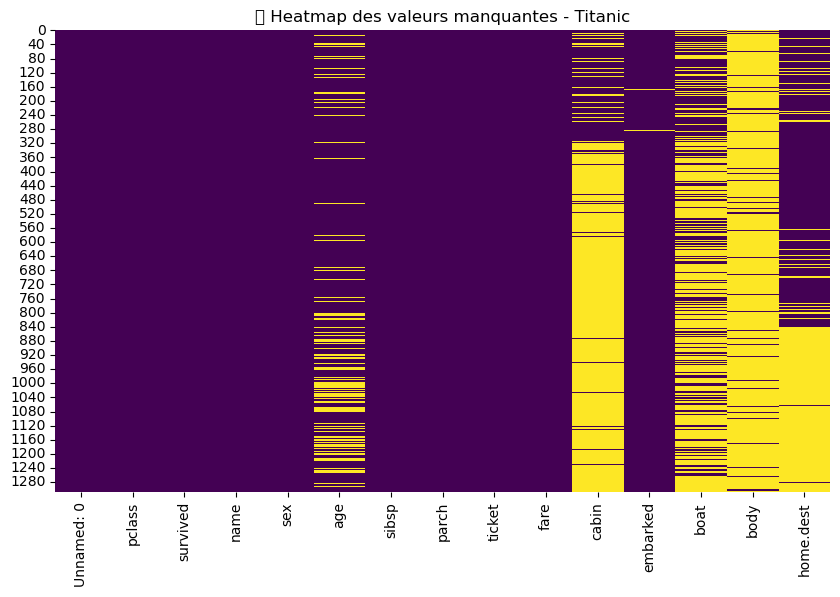

body          90.756303
cabin         77.463713
boat          62.872422
home.dest     43.086325
age           20.091673
embarked       0.152788
fare           0.076394
sibsp          0.000000
sex            0.000000
name           0.000000
survived       0.000000
Unnamed: 0     0.000000
pclass         0.000000
parch          0.000000
ticket         0.000000
dtype: float64

In [93]:
# Vérifions les valeurs manquantes avec un heatmap
plt.figure(figsize=(10,6))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis')
plt.title('🔎 Heatmap des valeurs manquantes - Titanic')
plt.show()
(   titanic.isnull().sum() / nbr_rows * 100).sort_values(ascending=False)

In [94]:
titanic.columns = [str.capitalize(col) for col in titanic.columns.tolist()]

👉 **Conclusions :**
- `Age` a beaucoup de valeurs manquantes → Imputation nécessaire.
- `Cabin` est trop manquant → À supprimer.
- `Embarked` a 2 valeurs manquantes → Remplacer par le mode.

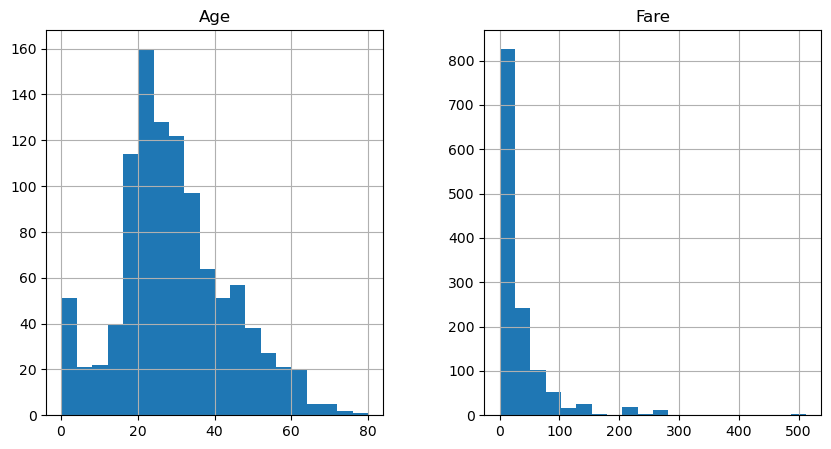

In [95]:
# Distribution des features numériques
titanic[['Age','Fare']].hist(bins=20, figsize=(10,5))
plt.show()

c:\Users\didie\anaconda3\envs\pythonDevIa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128697 (\N{MENS SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\didie\anaconda3\envs\pythonDevIa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128698 (\N{WOMENS SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


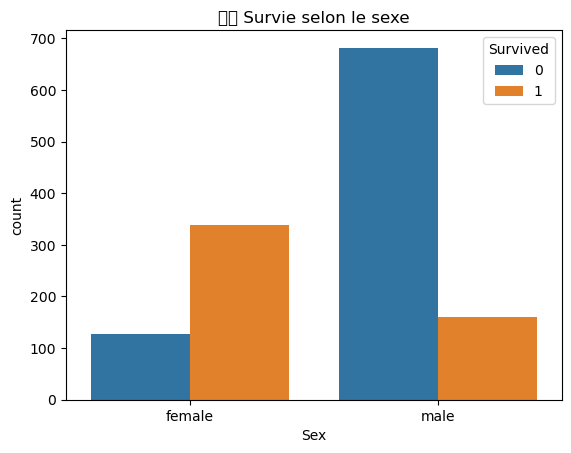

c:\Users\didie\anaconda3\envs\pythonDevIa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


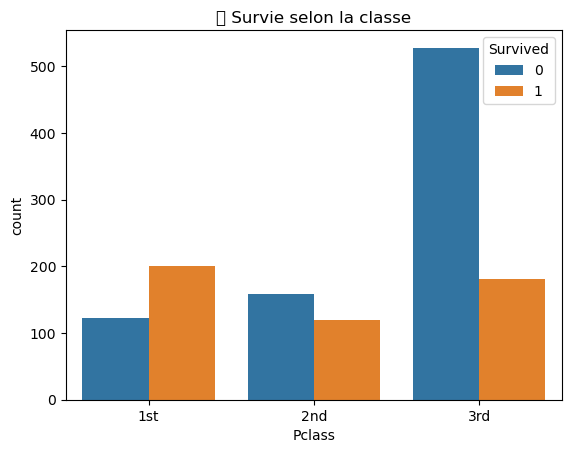

In [96]:
# Analyse categorical vs Survived
sns.countplot(data=titanic, x='Sex', hue='Survived')
plt.title('🚹🚺 Survie selon le sexe')
plt.show()
sns.countplot(data=titanic, x='Pclass', hue='Survived')
plt.title('🎟️ Survie selon la classe')
plt.show()

👉 Les femmes survivent beaucoup plus.
👉 Les passagers de 1ère classe survivent beaucoup plus que ceux de 3ème.

## 🔎 Feature Selection - Titanic

In [98]:
titanic = titanic.drop(columns=['Cabin','Ticket','Name', 'Boat', 'Body', 'Home.dest'], axis=1)


titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)
titanic['Fare'].fillna(titanic['Fare'].median(), inplace=True)


titanic_encoded = pd.get_dummies(titanic, drop_first=True)


X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

C:\Users\didie\AppData\Local\Temp\ipykernel_8540\2247165665.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
C:\Users\didie\AppData\Local\Temp\ipykernel_8540\2247165665.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

<Axes: >

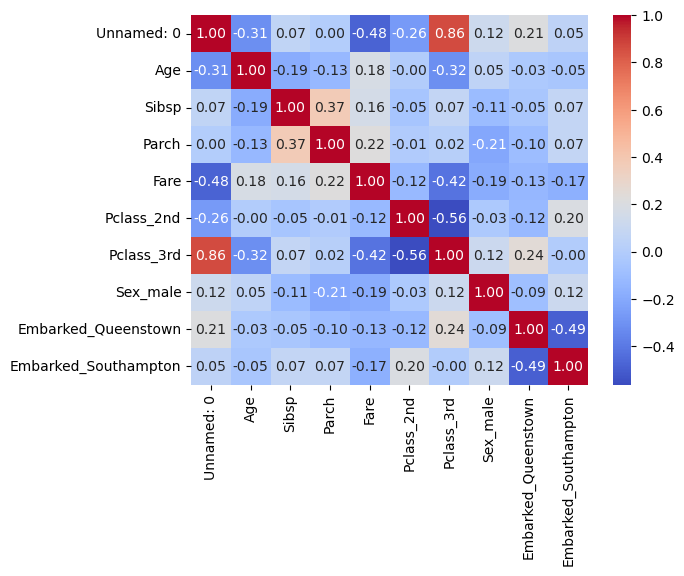

In [107]:
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [99]:
# Chi2
chi_scores, p_values = chi2(X, y)
chi2_results = pd.DataFrame({'Feature': X.columns,'Chi2 Score': chi_scores,'p-value': p_values})
chi2_results.sort_values(by='Chi2 Score', ascending=False)

,Feature,Chi2 Score,p-value
0,Unnamed: 0,24618.063049,0.000000e+00
4,Fare,6285.517303,0.000000e+00
7,Sex_male,130.254635,3.604427e-30
6,Pclass_3rd,48.198738,3.851362e-12
3,Parch,17.389928,3.044350e-05
1,Age,14.176524,1.664342e-04
9,Embarked_Southampton,8.906470,2.841621e-03
5,Pclass_2nd,2.662175,1.027601e-01
2,Sibsp,2.202718,1.377676e-01
8,Embarked_Queenstown,0.306335,5.799382e-01


In [100]:
# ANOVA F-test
f_scores, p_vals = f_classif(X, y)
anova_results = pd.DataFrame({'Feature': X.columns,'F Score': f_scores,'p-value': p_vals})
anova_results.sort_values(by='F Score', ascending=False)

,Feature,F Score,p-value
7,Sex_male,507.059297,3.775892e-95
0,Unnamed: 0,123.400025,1.849093e-27
6,Pclass_3rd,114.163838,1.320395e-25
4,Fare,83.038513,2.941574e-19
9,Embarked_Southampton,30.307086,4.434226e-08
3,Parch,8.991651,2.763423e-03
5,Pclass_2nd,3.380293,6.620711e-02
1,Age,2.514250,1.130632e-01
2,Sibsp,1.012712,3.144402e-01
8,Embarked_Queenstown,0.337675,5.612745e-01


In [101]:
importances.sort()

c:\Users\didie\anaconda3\envs\pythonDevIa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


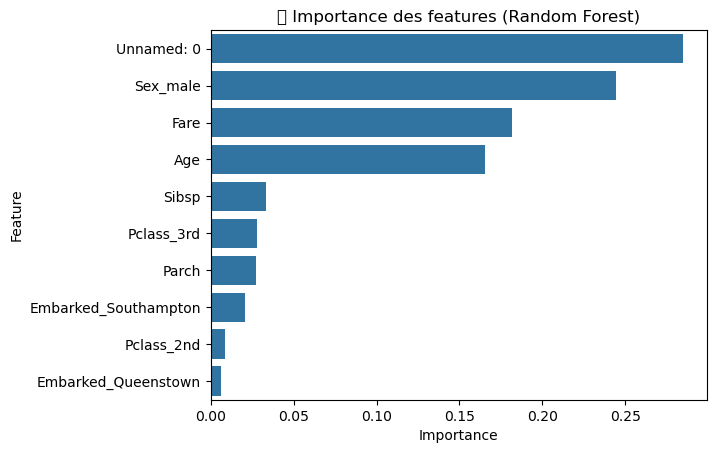

In [102]:
# Random Forest Importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_

importances_df = pd.DataFrame({'Feature': X.columns,'Importance': importances}).sort_values(by='Importance', ascending=False)


sns.barplot(x=importances_df['Importance'], y=importances_df['Feature'])
plt.title('🌲 Importance des features (Random Forest)')
plt.show()

👉 **Conclusion Titanic :** Les features les plus importantes sont :
- `Sex_male`, `Pclass`, `Fare`, `Age`.
- Les autres peuvent être secondaires.

## 🌸 Partie 2 : Iris Dataset

In [103]:
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


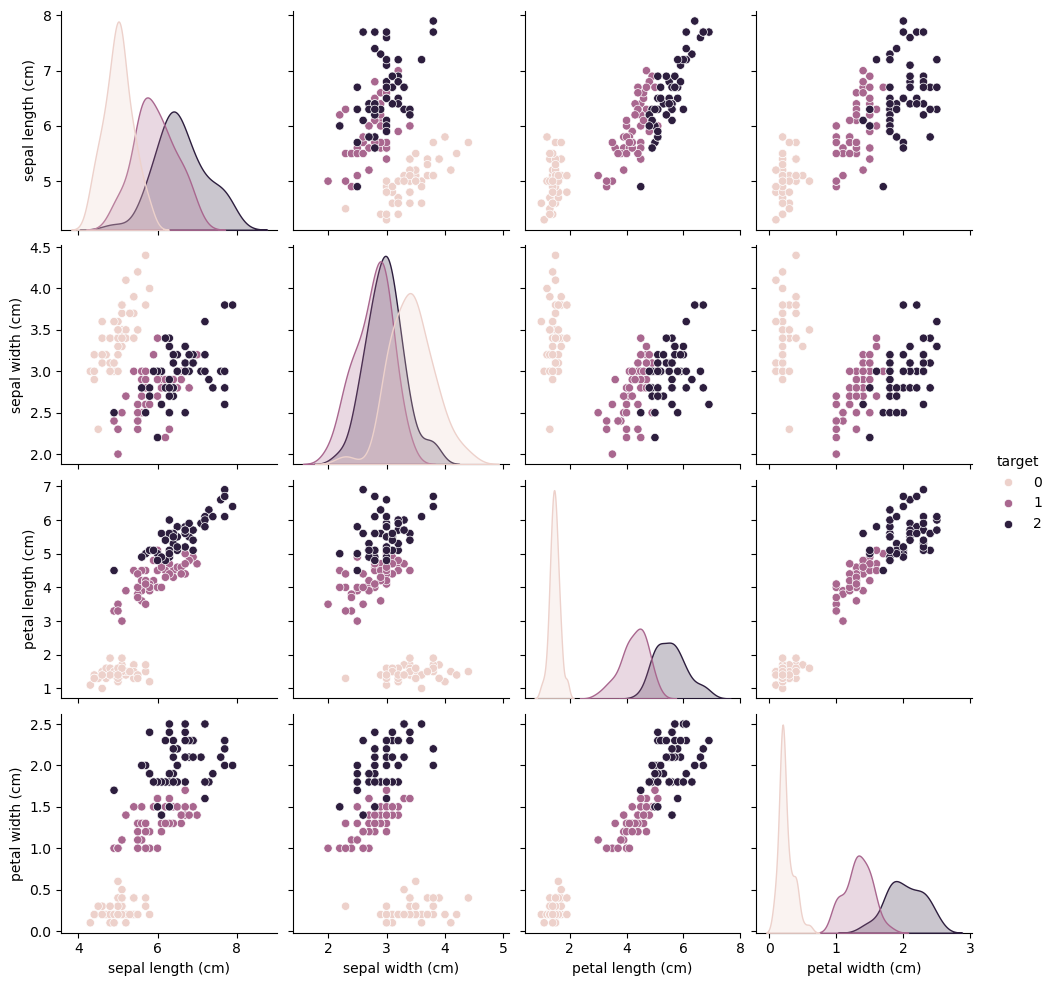

In [104]:
sns.pairplot(df_iris, hue='target')
plt.show()

👉 On observe que `petal_length` et `petal_width` séparent bien les classes.

In [105]:
X_iris = df_iris.drop('target', axis=1)
y_iris = df_iris['target']
f_scores, p_vals = f_classif(X_iris, y_iris)
anova_iris = pd.DataFrame({'Feature': X_iris.columns,'F Score': f_scores,'p-value': p_vals})
anova_iris.sort_values(by='F Score', ascending=False)

,Feature,F Score,p-value
2,petal length (cm),1180.161182,2.856777e-91
3,petal width (cm),960.007147,4.169446e-85
0,sepal length (cm),119.264502,1.669669e-31
1,sepal width (cm),49.160040,4.492017e-17


👉 **Conclusion Iris :**
- `petal_length` et `petal_width` sont les meilleurs discriminateurs.
- `sepal_length` et `sepal_width` ont moins d’impact.